# Vietnam — Full Piotroski F-Score Study

The proposal's complete loop on **real data**: point-in-time universe →
high-B/M value subset → 9-signal F-Score → fixed-basket selection (F-Score vs
value / market-cap / liquidity-matched / random Monte-Carlo) → EW / GMV /
sector-capped GMV on RMT-cleaned covariances, plus a dollar-neutral
long-short book (long top-k scores, short bottom-k) where shorting is
available → annual-rebalance backtest →
placement in the random distribution → investable benchmarks → Fama-French
three-factor regression.

**Data & scope.** Everything Vietnamese comes from the team's own preprocessing pipeline in `src/fscore_vietnam`, which crawls FireAnt, CafeF and TCBS into `fscore.db`, reconciles the three, applies accounting checks, **scores the nine signals**, and writes a per-firm-year panel — FY2009 onward, the span the Vietnamese sources cover. This notebook READS that score panel; it does not recompute it, so there is one Vietnamese F-Score and one place it is defined. `src/fscore_vietnam/schema_adapter_util.py` adds only what the export omits — book equity and year-end market value for the B/M sort, the sector map, and the VN30/VNINDEX levels. `report_date` is the 31 December fiscal year end (the panel carries no filing date), and the reporting lag is **6 months**: 31 December + 6 months = 30 June, the last day before a 1 July formation. That is the most conservative rule that still admits the prior fiscal year, and it is the same screening date the pipeline itself screens on, so both halves select on the same information. Formations run **July 2012 .. July 2024** — thirteen chained holding years, the same calendar as the US and Japan. The price cache reaches August 2026 and would support a July 2025 formation, but taking it would move the goalposts relative to the other two markets. Survivorship is **partial rather than total**: the price panel does retain lines that died inside the sample — 125 of its 1,371 tickers print for the last time before 2026, spread across 2012-2025 — but names the vendor no longer resolves at all leave no trace to count, so the residual is unquantified. Covariances are estimated on 36 months of daily returns ending the day before formation.

Run `python scripts/schema_adapter_util.py`
once before this notebook (builds the git-ignored cache under `data/`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.plotting import setup_plots, save_fig
from fscore.data.yahoo import load_cached
from fscore.pipeline import run_study
from fscore.evaluation import (metrics, benchmark_returns, fetch_ff_factors,
                               factor_regression, to_usd)
from fscore.evaluation import local_ff3_factors

setup_plots()      # study-wide figure defaults; every saved chart is 300 dpi
RESULTS_FIG = ROOT / "results" / "figures"
MARKET = "vietnam"
YEARS = list(range(2012, 2025))
LAG_MONTHS = 6  # report_date = 31 Dec fiscal year end; +6m = 30 Jun, the day before formation
END_CAP = None   # every holding year is complete; nothing is truncated
fund, prices, sectors, bench = load_cached(MARKET, ROOT / "data")
membership = None
from fscore.data.fs_clean import load_scores
SCORES = load_scores(MARKET, ROOT / "data")   # scored upstream, see fscore_vietnam.schema_adapter
print(f"fundamentals: {fund.ticker.nunique()} tickers, "
      f"FY{fund.fiscal_year.min()}–FY{fund.fiscal_year.max()}")
print(f"prices: {prices.ticker.nunique()} tickers, "
      f"{prices.date.min():%Y-%m-%d} → {prices.date.max():%Y-%m-%d}")
if SCORES is not None:
    print(f"scores: {len(SCORES):,} firm-years, "
          f"{int(SCORES.score_year.min())}–{int(SCORES.score_year.max())} "
          f"(read, not recomputed)")
fund.groupby("fiscal_year").size().rename("statements")

fundamentals: 1805 tickers, FY2009–FY2025
prices: 1371 tickers, 2009-01-02 → 2026-08-07
scores: 9,482 firm-years, 2011–2025 (read, not recomputed)


fiscal_year
2009     525
2010     751
2011     875
2012     984
2013    1060
2014    1111
2015    1255
2016    1369
2017    1482
2018    1544
2019    1584
2020    1541
2021    1516
2022    1453
2023    1419
2024    1413
2025    1351
Name: statements, dtype: int64

### 1. Run the multi-year study

Per formation year: universe = top-150 names by median dollar volume with
continuous listing and complete, published statements; value subset = top 40%
by B/M (~60 names); baskets of 30; 1,000 random baskets under EW (300 pushed
through the GMV / sector-GMV pipeline).

**Data discarded before any test.** A firm-year is scored
only when all nine signals are computable; partial scores are dropped rather
than summed over whatever is available (an incomplete score is not a low
score). Where the signals are computed here, that needs three fiscal years —
T-1 and T-2 for the levels, T-3 total assets for the prior year's scaling —
and the per-formation count is `dropped_incomplete_signals` in the
diagnostics below. Where the score panel arrives ready-made (`SCORES`), the
same rule was applied upstream and the count lives in that market's own
exclusion table, so the diagnostic reads `NaN` rather than a misleading
zero.

In [2]:
study = run_study(MARKET, fund, prices, sectors, YEARS,
                  n_mc=1000, n_mc_opt=300, lag_months=LAG_MONTHS,
                  scores=SCORES,   # None => signals computed from `fund`
                  membership=membership, end_cap=END_CAP, seed=42,
                  detone=False)   # RMT denoise only — detoning is
                                  # out of scope for this study
diag = pd.DataFrame([{"year": yr.year, **yr.diagnostics} for yr in study.yearly])
diag.set_index("year")

,universe,value_set,scored,dropped_incomplete_signals,tie_break_slots,cov_est_days,delisted_in_holding_year,k,fscore_mean,fscore_basket_min
year,,,,,,,,,,
2012,150,60,60,NaN,12,749,1,30,4.533333,5
2013,150,60,60,NaN,12,746,0,30,4.783333,5
2014,150,60,60,NaN,10,746,2,30,4.783333,5
2015,150,60,60,NaN,4,743,0,30,5.350000,5
2016,150,60,60,NaN,7,746,0,30,4.933333,5
2017,150,60,60,NaN,9,749,1,30,4.750000,5
2018,150,60,60,NaN,7,752,0,30,4.983333,5
2019,150,60,60,NaN,13,748,1,30,5.500000,6
2020,150,60,60,NaN,8,750,0,30,5.133333,5


### 2. F-Score distribution within the value universe, per formation

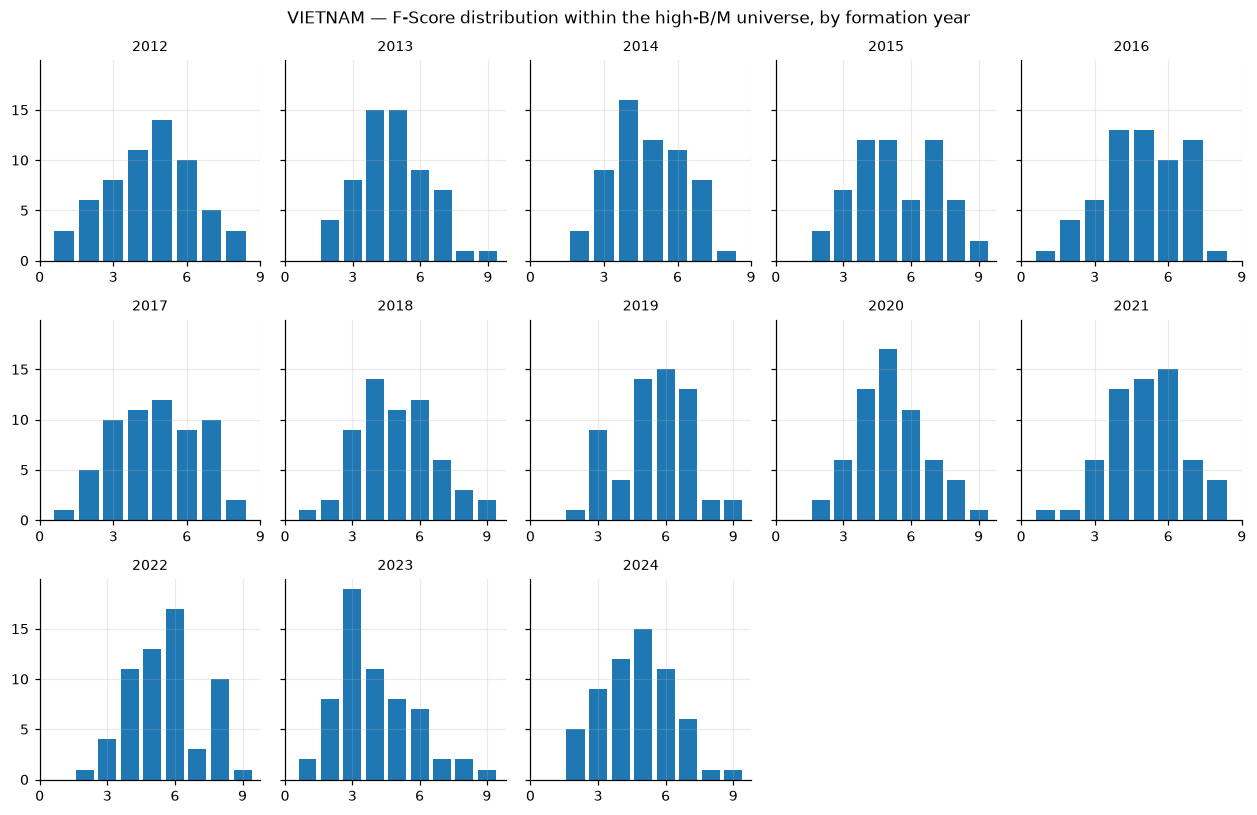

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.0,60.00,60.00,60.00,60.00,60.00
mean,4.53,4.78,4.78,5.35,4.93,4.75,4.98,5.5,5.13,5.12,5.58,4.00,4.75
std,1.79,1.55,1.47,1.84,1.62,1.72,1.74,1.6,1.55,1.52,1.60,1.75,1.59
min,1.00,2.00,2.00,2.00,1.00,1.00,1.00,2.0,2.00,1.00,2.00,1.00,2.00
25%,3.00,4.00,4.00,4.00,4.00,3.00,4.00,5.0,4.00,4.00,4.00,3.00,4.00
50%,5.00,5.00,5.00,5.00,5.00,5.00,5.00,6.0,5.00,5.00,6.00,4.00,5.00
75%,6.00,6.00,6.00,7.00,6.00,6.00,6.00,7.0,6.00,6.00,6.00,5.00,6.00
max,8.00,9.00,8.00,9.00,8.00,8.00,9.00,9.0,9.00,8.00,9.00,9.00,9.00


In [3]:
ncol = min(5, len(YEARS))
nrow = -(-len(YEARS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(2.3 * ncol, 2.5 * nrow),
                         sharey=True, squeeze=False)
for ax, yr in zip(axes.flat, study.yearly):
    counts = yr.scored.fscore.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{yr.year}", fontsize=9); ax.set_xticks(range(0, 10, 3))
for ax in axes.flat[len(study.yearly):]:
    ax.axis("off")
fig.suptitle(f"{MARKET.upper()} — F-Score distribution within the high-B/M universe, by formation year")
plt.tight_layout(); save_fig(f"{MARKET}_fscore_distribution", directory=RESULTS_FIG); plt.show()

pd.DataFrame({yr.year: yr.scored.fscore.describe() for yr in study.yearly}).round(2)

### 3. Chained track record vs investable benchmarks

Both indices are VND, like the portfolios — no currency effect enters this row. They are, however, **capital indices**: neither reinvests cash dividends, while the portfolios are built on dividend-adjusted closes. The gap is the index dividend yield, historically around 1.5-2% a year, and it flatters every portfolio against these two rows by that much. No total-return version of either index exists in the source database, so this is disclosed rather than corrected.

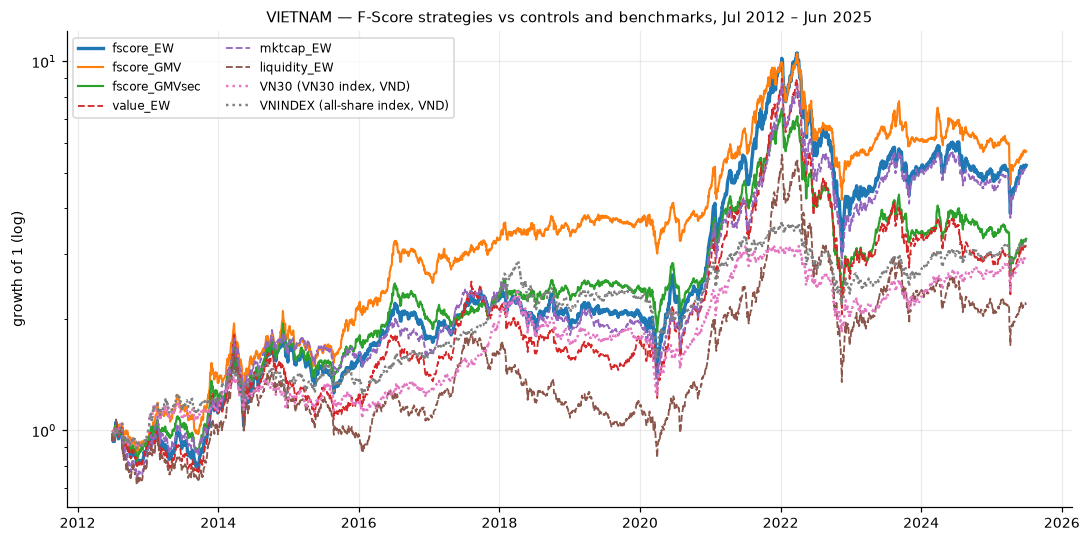

In [4]:
BENCH = {"VN30 (VN30 index, VND)": "VN30",
         "VNINDEX (all-share index, VND)": "VNINDEX"}
start, end = study.daily.index.min(), study.daily.index.max()
bench_rets = {name: benchmark_returns(bench, tk, start, end)
              for name, tk in BENCH.items()}

nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 5))
# solid for the F-Score variants, dashed for the controls; a strategy not
# named here still plots, so adding one never breaks the figure
styles = {"fscore_EW": ("-", 2.2), "fscore_GMV": ("-", 1.4), "fscore_GMVsec": ("-", 1.4),
          "fscore_LS": ("-", 1.4),
          "value_EW": ("--", 1.2), "mktcap_EW": ("--", 1.2), "liquidity_EW": ("--", 1.2)}
for s in study.daily.columns:
    ls, lw = styles.get(s, ("-" if s.startswith("fscore") else "-.", 1.2))
    ax.plot(nav.index, nav[s], ls, lw=lw, label=s)
for name, r in bench_rets.items():
    ax.plot((1 + r).cumprod(), ":", lw=1.6, label=name)
ax.set_ylabel("growth of 1 (log)"); ax.set_yscale("log")
ax.set_title(f"{MARKET.upper()} — F-Score strategies vs controls and benchmarks, "
             f"{start:%b %Y} – {end:%b %Y}")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
save_fig(f"{MARKET}_nav_vs_benchmarks", directory=RESULTS_FIG); plt.show()

In [5]:
tbl = study.summary()      # gross first; costs follow separately
for name, r in bench_rets.items():
    tbl.loc[name] = metrics(r)   # benchmarks are buy-and-hold: no turnover
tbl[["ann_return", "ann_vol", "sharpe", "max_drawdown",
     "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.138,0.256,0.537,-0.711,30.0,30.000
fscore_GMV,0.145,0.227,0.640,-0.599,30.0,7.368
fscore_GMVsec,0.098,0.235,0.416,-0.703,30.0,9.181
value_EW,0.094,0.271,0.347,-0.770,30.0,30.000
mktcap_EW,0.136,0.256,0.531,-0.687,30.0,30.000
liquidity_EW,0.064,0.263,0.242,-0.758,30.0,30.000
"VN30 (VN30 index, VND)",0.089,0.188,0.474,-0.481,NaN,NaN
"VNINDEX (all-share index, VND)",0.097,0.180,0.537,-0.453,NaN,NaN


`nominal_k` is the basket size, `effective_n` is 1/Σw² —
an optimised or sector-capped book concentrates, so the two are not the same
number of holdings. Turnover and the net-of-cost sensitivity follow below.

In [6]:
tbl[["turnover", "cost_drag",
     "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.7066,0.0028,0.1347,0.5258
fscore_GMV,0.9077,0.0036,0.1418,0.6239
fscore_GMVsec,0.8881,0.0036,0.0941,0.4009
value_EW,0.6263,0.0025,0.0916,0.3381
mktcap_EW,0.5323,0.0021,0.1336,0.5229
liquidity_EW,0.7309,0.0029,0.0607,0.2308
"VN30 (VN30 index, VND)",NaN,NaN,NaN,NaN
"VNINDEX (all-share index, VND)",NaN,NaN,NaN,NaN


### 4. Statistical control — placement in the Monte-Carlo random distribution

Same universe, same basket size, same construction pipeline; the only
difference is *which* 30 names. Percentile = share of random baskets the
F-Score portfolio beats; the p-value is one-sided and judged at the study's
single significance level, **5%** (`significant` column). No 1% or 10% tier
is used, so p = 0.06 counts as not significant.

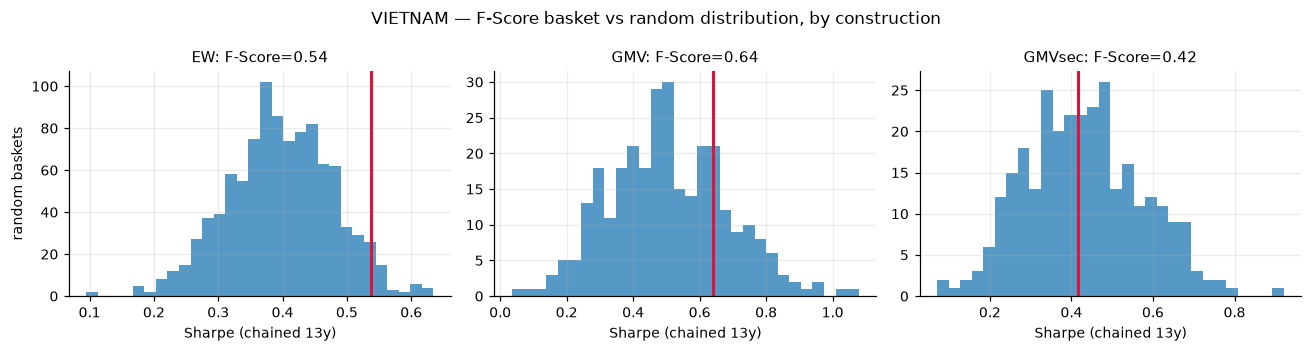

fscore random_mean random_std percentile  \
fscore_EW     ann_return    0.137563    0.102559   0.021071      0.958   
              sharpe        0.536779    0.396737   0.081899      0.963   
              max_drawdown -0.710512   -0.735679   0.018633      0.909   
fscore_GMV    ann_return    0.145397    0.117758   0.041074       0.75   
              sharpe        0.639887    0.505398   0.177248   0.783333   
              max_drawdown -0.598586   -0.668199   0.047749       0.94   
fscore_GMVsec ann_return    0.097625    0.102521   0.034202       0.46   
              sharpe        0.416064    0.430004   0.144179   0.483333   
              max_drawdown -0.703402   -0.700203   0.029044       0.43   

                             p_value significant n_draws  
fscore_EW     ann_return       0.042        True    1000  
              sharpe           0.037        True    1000  
              max_drawdown     0.091       False    1000  
fscore_GMV    ann_return        0.25       False     300  
              sharpe        0.216667       False     300  
              max_drawdown      0.06       False     300  
fscore_GMVsec ann_return        0.54       False     300  
              sharpe        0.516667       False     300  
              max_drawdown      0.57       False     300

In [7]:
pairs = [("EW", "fscore_EW"), ("GMV", "fscore_GMV"), ("GMVsec", "fscore_GMVsec")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)
for ax, (how, strat) in zip(axes, pairs):
    sharpes = study.mc_summary(how)["sharpe"].dropna()
    fs = metrics(study.daily[strat].dropna())["sharpe"]
    ax.hist(sharpes, bins=30, alpha=0.75)
    ax.axvline(fs, color="crimson", lw=2)
    ax.set_title(f"{how}: F-Score={fs:.2f}", fontsize=10)
    ax.set_xlabel(f"Sharpe (chained {len(YEARS)}y)")
axes[0].set_ylabel("random baskets")
fig.suptitle(f"{MARKET.upper()} — F-Score basket vs random distribution, by construction")
plt.tight_layout(); save_fig(f"{MARKET}_mc_placement", directory=RESULTS_FIG); plt.show()

placements = pd.concat({strat: study.placement(strat, how) for how, strat in pairs})
placements.round(3)

### 5. Turnover and implied trading cost

One-way turnover per rebalance, computed on each strategy's actual weights
(so GMV pays for weight drift, not just for name changes); cost drag =
2 x turnover x 20 bp per side, already applied in the `net_*` columns above.
For reference, the random control is redrawn every year and turns over
roughly `1 - k/|universe|`, i.e. in the same range as the F-Score basket.

In [8]:
to = study.turnover_table()
to.loc["mean"] = to.mean()
cost = (2 * to.loc["mean"] * 0.0020).rename("annual cost drag")
pd.concat([to.round(3).T, cost.round(4)], axis=1)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,mean,annual cost drag
fscore_EW,0.679,0.567,0.637,0.814,0.705,0.778,0.566,0.716,0.821,0.751,0.785,0.658,0.707,0.0028
fscore_GMV,0.981,0.769,0.718,0.997,0.910,0.979,0.792,0.829,1.000,1.000,0.981,0.936,0.908,0.0036
fscore_GMVsec,0.979,0.671,0.736,0.960,0.947,0.977,0.695,0.800,0.952,0.966,1.000,0.973,0.888,0.0036
value_EW,0.720,0.548,0.685,0.778,0.693,0.721,0.620,0.510,0.500,0.547,0.650,0.546,0.626,0.0025
mktcap_EW,0.513,0.407,0.524,0.738,0.546,0.504,0.469,0.525,0.501,0.597,0.626,0.437,0.532,0.0021
liquidity_EW,0.757,0.491,0.779,0.831,0.771,0.782,0.709,0.789,0.727,0.831,0.684,0.619,0.731,0.0029


### 6. Does alpha survive the factor exposures?

Daily excess returns regressed on three factors (market, size, value) with
Newey-West standard errors. The `alpha_significant` column is the verdict at
the study's single level, 5%.

**The factors are local, not Ken French's.** The library covers the US, Japan
and the developed regions; it does not cover Vietnam, and no free substitute
does. Skipping the regression would leave the study's only emerging market
without the one test that strips style exposure out of the result, so the
factors are built here from the same point-in-time panel the study already
uses — a 2x3 size / book-to-market sort, formed 1 July on fiscal T-1
statements, value-weighted and held for twelve months
(`fscore.evaluation.local_ff3_factors`). Two consequences: the market leg is
this panel's eligible universe rather than the whole exchange, and market cap
is measured at the fiscal year end rather than at formation. The alphas below
are therefore alphas against a *local approximation* of the three factors,
and are not comparable coefficient-for-coefficient with the US and Japan
tables above.

In [9]:
ff = local_ff3_factors(fund, prices, YEARS, lag_months=LAG_MONTHS)
series = {s: study.daily[s].dropna()
          for s in ["fscore_EW", "fscore_GMV", "value_EW"]}
reg = pd.DataFrame({s: factor_regression(r, ff) for s, r in series.items()}).T
reg.round(4)

,alpha_daily,alpha_annual,alpha_tstat,alpha_pvalue,alpha_significant,alpha,beta_mkt,beta_smb,beta_hml,r2,n_obs
fscore_EW,-0.000156,-0.039354,-1.083956,0.278384,False,0.05,1.148391,0.136512,0.899346,0.78817,3235
fscore_GMV,-0.000037,-0.009289,-0.199887,0.841569,False,0.05,1.005389,0.332391,0.664465,0.535597,3235
value_EW,-0.00037,-0.09316,-2.395693,0.016589,True,0.05,1.164236,0.291247,1.180098,0.781246,3235


In [10]:
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
tbl.to_csv(RESULTS / f"{MARKET}_summary.csv")
placements.to_csv(RESULTS / f"{MARKET}_mc_placement.csv")
to.to_csv(RESULTS / f"{MARKET}_turnover.csv")
reg.to_csv(RESULTS / f"{MARKET}_factor_regression.csv")
diag.to_csv(RESULTS / f"{MARKET}_diagnostics.csv", index=False)
print("saved to", RESULTS)

saved to /Users/lap14821-local/Documents/Software Development/worldquant_uni/fscore_capstone/results


### 7. Reading the results

*(filled in after execution)*